In [2]:
#LOAD DATA
import os
from tensorflow.keras.utils import load_img,img_to_array

dataset_path='/content/drive/MyDrive/prac_dataset/Cat-and-dog'
X,y=[],[]
for label in os.listdir(dataset_path):
  for img_file in os.listdir(os.path.join(dataset_path,label)):
    img = load_img(os.path.join(dataset_path,label,img_file),
                   target_size=(224,224))
    X.append(img_to_array(img))
    y.append(label)

In [3]:
#PREPROCESS
import numpy as np
from sklearn.preprocessing import LabelEncoder

X=np.array(X)/255.0
y=LabelEncoder().fit_transform(y)

#SPLIT
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [4]:
#BUILD MODEL
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

#As it is
base1 = VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))
base1.trainable=False
model1 = Sequential([
    base1,
    GlobalAveragePooling2D(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

#unfreeze last layer
base2 = VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))
base2.trainable=False
base2.layers[-1].trainable=True
model2 = Sequential([
    base2,
    GlobalAveragePooling2D(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

#unfreeze last 20 layers
base3 = VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))
base3.trainable=False
for layer in base3.layers[-20:]:
  layer.trainable=True
model3 = Sequential([
    base3,
    GlobalAveragePooling2D(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Acc: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
<Sequential name=sequential, built=True>
Predicted class: Cat
Actual class: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
Acc: 0.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step
<Sequential name=sequential_1, built=True>
Predicted class: Dog
Actual class: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
Acc: 0.5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
<Sequential name=sequential_2, built=True>
Predicted class: Dog
Actual class: Cat


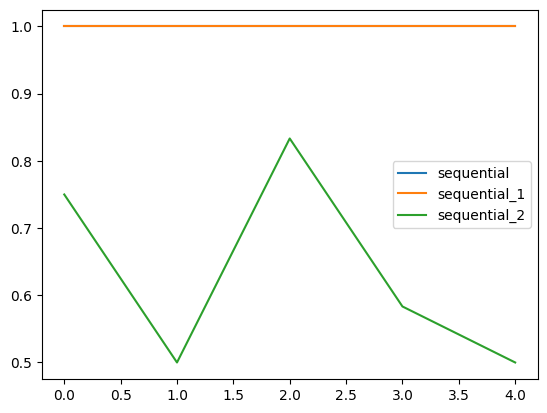

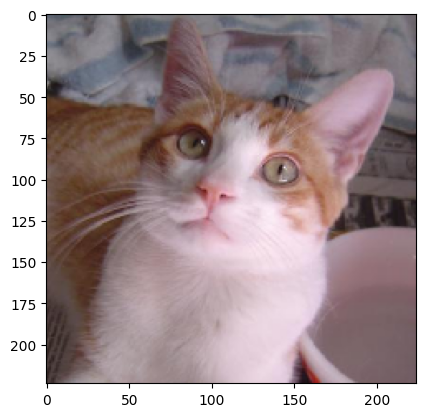

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
models=[model1,model2,model3]
for model in models:
  model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

  history = model.fit(X_train,y_train,
            validation_data=(X_val,y_val),
            epochs=5,
            verbose=0)

  plt.plot(history.history['accuracy'],label=model.name)
  plt.xlabel='epoch'
  plt.ylabel='Accuracy'
  plt.legend()

  y_pred=(model.predict(X_test)>0.5).astype(int)
  print("Acc:",accuracy_score(y_test,y_pred))

  sample=X_test[0].reshape(1,224,224,3)
  pred=model.predict(sample)
  print(model)
  print("Predicted class:","Cat" if pred<0.5 else "Dog")
  print("Actual class:","Cat" if y_test[0] <0.5 else "Dog")
plt.show()
plt.imshow(X_test[0])
